In [26]:
import cv2
from matplotlib import pyplot as plt
from Utils.load_utils import load_bsds500
from noises.fourier.fourier_gauss import fourier_gaussian_filter
from noises.fourier.fourier_wiener import fourier_wiener_denoise
from noise import add_gaussian_noise
from noises.fourier.fourier_filter import fourier_denoise
# https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
import numpy as np
from scipy import fftpack

bsds_path = "BSR\BSDS500"

data = load_bsds500(bsds_path, images_only= False)



Loading splits:   0%|          | 0/3 [00:00<?, ?it/s, current=train]

BSR\BSDS500\data\groundTruth\train


Loading splits:  33%|███▎      | 1/3 [00:00<00:01,  1.31it/s, current=test] 

BSR\BSDS500\data\groundTruth\test


Loading splits:  67%|██████▋   | 2/3 [00:01<00:00,  1.36it/s, current=val] 

BSR\BSDS500\data\groundTruth\val


Loading splits:  33%|███▎      | 1/3 [00:00<00:00,  5.74it/s, current=test] 

BSR\BSDS500\data\images\train
BSR\BSDS500\data\images\test


Loading splits: 100%|██████████| 3/3 [00:00<00:00,  6.90it/s, current=val] 

BSR\BSDS500\data\images\val


In [27]:
from metrics import calculate_ODS

from Utils.plot_utils import show_fft_magnitude


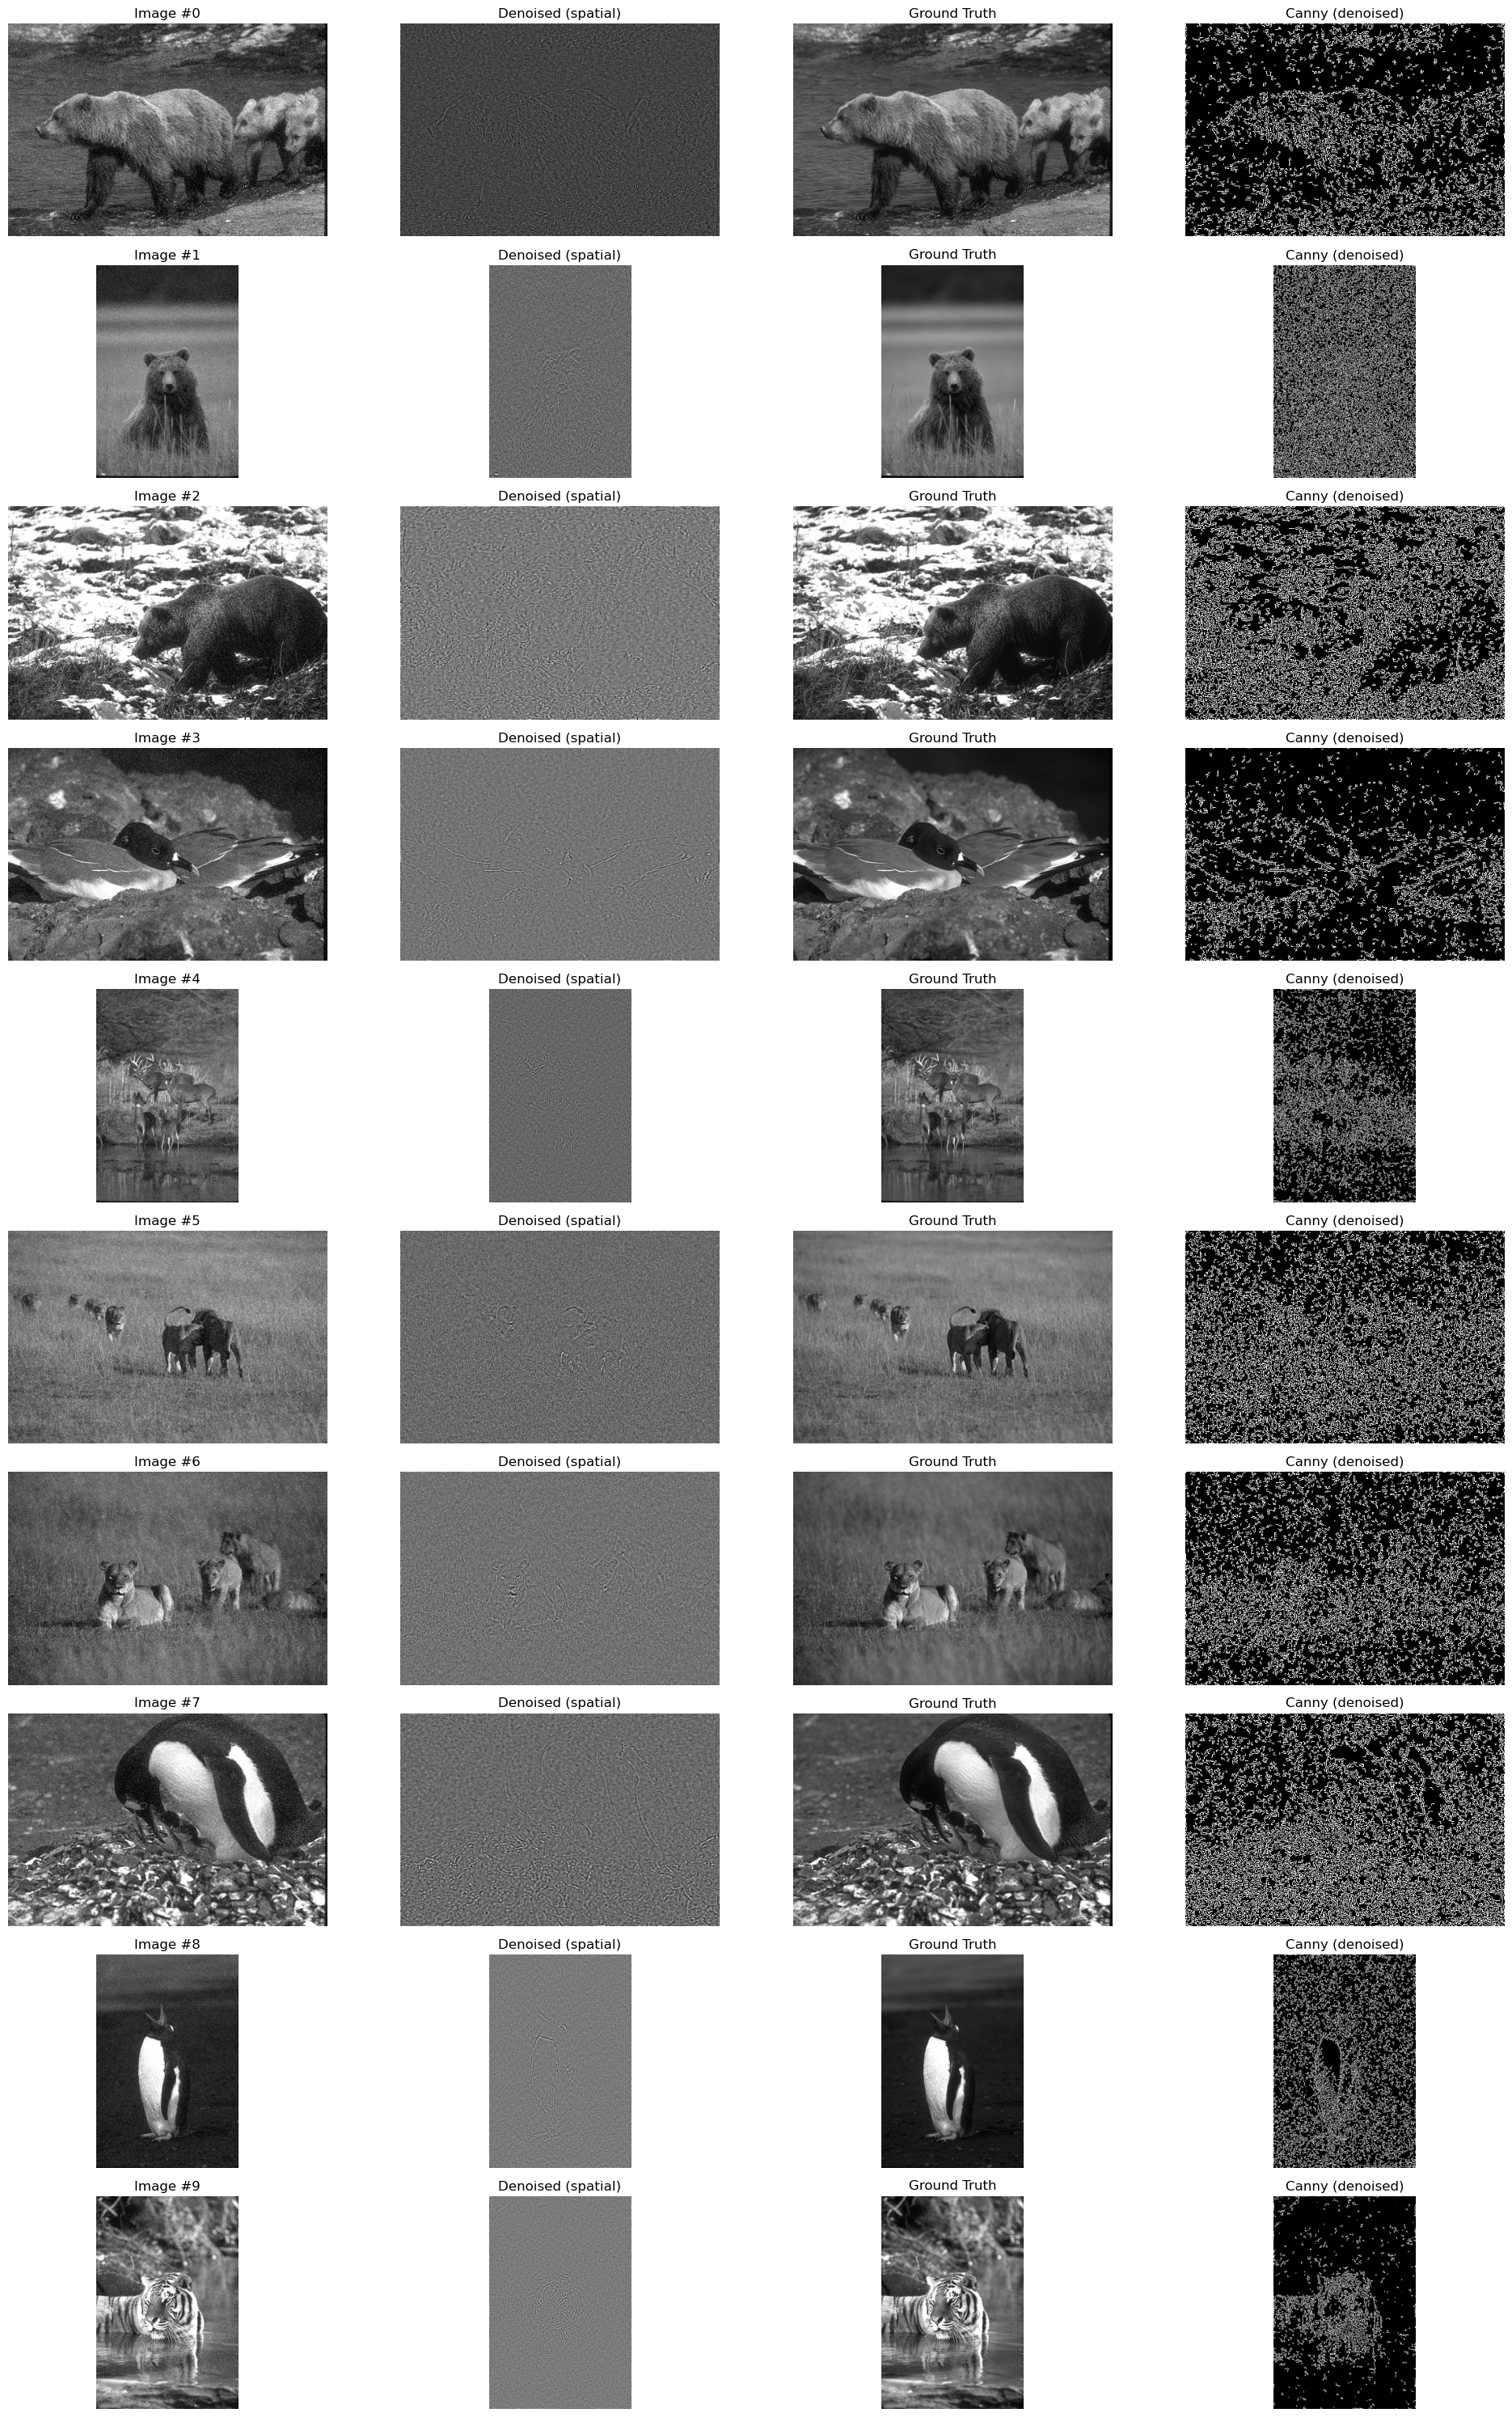

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import fftpack  # make sure this is imported

n_show = 10
fig, axes = plt.subplots(n_show, 4, figsize=(20, 3 * n_show))

for i in range(n_show):
    img = data["images"]["train"][i]
    gt  = data["edges"]["train"][i]

    if hasattr(img, "cpu"):
        img = img.cpu().numpy()
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))

    if img.ndim == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    if img_gray.dtype != np.uint8:
        img_gray = np.clip(img_gray, 0, 1)
        img_gray = (img_gray * 255).astype(np.uint8)

    img_noised = add_gaussian_noise(img_gray, 0, 20, 1)
    denoised = fourier_denoise(img_noised, percentile= 40, K = 50)
    denoised = denoised - denoised.min()
    if denoised.max() > 0:
        denoised = denoised / denoised.max()
    denoised = (denoised * 255).astype(np.uint8)


    edges = cv2.Canny(denoised, threshold1=100, threshold2=200)

    if hasattr(gt, "cpu"):
        gt = gt.cpu().numpy()
    gt = np.squeeze(gt)

    axes[i, 0].imshow(img_noised, cmap='gray' if img.ndim == 2 else None)
    axes[i, 0].set_title(f"Image #{i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(denoised, cmap="gray")
    axes[i, 1].set_title("Denoised (spatial)")
    axes[i, 1].axis("off")


    axes[i, 2].imshow(img, cmap="gray")
    axes[i, 2].set_title("Ground Truth")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(edges, cmap="gray")
    axes[i, 3].set_title("Canny (denoised)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()
